In [1]:
import json, os, pretty_midi, music21, io
pretty_midi.pretty_midi.MAX_TICK = 1.1e9 # pretty_midi의 MAX_TICK 값을 늘려서 MIDI 파일의 최대 tick 수를 증가시킴
import warnings
from music21.musicxml.xmlToM21 import MusicXMLWarning
warnings.filterwarnings("ignore", category=MusicXMLWarning)

/Users/simhyeongju/AVAPT/.venv/lib/python3.10/site-packages/pretty_midi/instrument.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
MIDI_METADATA_PATH = "/Users/simhyeongju/AVAPT/data/CIPI/index.json"
with open(MIDI_METADATA_PATH, 'r', encoding='utf-8') as f:
    raw = json.load(f)

MIDI_PATH_FRONT = "/Users/simhyeongju/AVAPT/data/CIPI/scores/"
cipi_midi_len_list = []
for name, item in raw.items():
    try:
        musicxml_paths = item["path"]
        total_time = 0
        for _, path in musicxml_paths.items():
            xml_path = os.path.join(MIDI_PATH_FRONT, path)
            score = music21.converter.parse(xml_path)
            midi_file_obj = score.write('midi')
            with open(midi_file_obj, 'rb') as f:
                midi_data = io.BytesIO(f.read())
            midi = pretty_midi.PrettyMIDI(midi_data)
            total_time += midi.get_end_time()
        cipi_midi_len_list.append(total_time)
        print(name, total_time)
    except Exception as e:
        print(f"Error processing {name}: {e}")
        continue

print(cipi_midi_len_list)

c-1 1779.98265
c-10 1170.8869605
c-11 1688.9741350000002
c-12 1870.4380945
c-13 1242.7814201666665
c-14 1067.765926
c-15 1754.8853955
c-16 1340.909261375
c-17 1275.60210525
c-18 2897.8
c-180 886.124917
c-181 2724.0
c-182 297.25
Error processing c-183: cannot expand Stream: badly formed repeats or repeat expressions
c-184 322.875
c-185 701.5
Error processing c-186: cannot expand Stream: badly formed repeats or repeat expressions
c-187 424.251978
c-188 287.528881
c-189 351.5
c-19 417.84188900000004
c-190 476.8826399999999
c-191 244.5
c-192 188.035614
c-193 382.0
c-194 269.99985599999997
c-195 471.6
c-196 371.53808999999995
c-197 331.81834499999997
c-198 247.5
c-199 372.69225800000004
c-2 2296.6735200000003
c-20 509.681655
c-200 162.222352
c-201 267.00937500000003
c-202 110.833422
c-203 430.0
c-204 288.0
c-205 58.9874741875
c-206 394.75
c-207 360.00208333333336
c-208 223.163064
c-209 618.6907247458333
c-21 1610.516424
c-210 728.0007936507936
c-211 366.59583333333336
c-212 104.00625
c-213 

In [4]:
MIDI_METADATA_PATH = "/Users/simhyeongju/AVAPT/data/Mikrokosmos-difficulty/metadata/henle_mikrokosmos.json"
with open(MIDI_METADATA_PATH, 'r', encoding='utf-8') as f:
    raw = json.load(f)

MIDI_PATH_FRONT = "/Users/simhyeongju/AVAPT/data/Mikrokosmos-difficulty/midi/"
mikrokosmos_midi_len_list = []
for name, item in raw.items():
    midi_path = os.path.join(MIDI_PATH_FRONT, name + ".mid")
    midi = pretty_midi.PrettyMIDI(midi_path)
    total_time = midi.get_end_time()
    mikrokosmos_midi_len_list.append(total_time)
    print(name, total_time)

1 20.0
2 40.0
3 30.0
4 20.0
5 48.461532000000005
6 20.769228000000002
7 29.999983999999998
8 28.59375
9 35.0
10 38.88892
11 27.428544
12 21.9
13 30.0
14 35.769226
15 25.161292
16 50.76922400000001
17 30.0
18 20.0
19 29.999996000000003
20 38.4
21 21.230748000000002
22 28.235264
23 30.0
24 33.5
25 58.0
26 36.6
27 35.0
28 29.999983999999998
29 29.999983999999998
30 51.428544
31 35.625
32 48.461532000000005
33 37.50003
34 39.0
35 76.235256
36 39.09087
37 33.103424
38 15.0
39 29.999992
40 37.0
41 39.545458499999995
42 81.69638499999999
45 37.674396
46 54.5
47 30.909128
48 52.173919999999995
49 23.2
50 31.2
51 56.481869999999994
52 17.142848
53 35.555583999999996
54 13.333344
56 14.583345
57 94.285664
58 49.56520499999999
59 42.631596
60 34.82141
61 50.00002
62 38.0952
63 36.428551999999996
64 26.538504
66 66.66672
67 34.90912
69 83.571462
70 65.45455199999999
71 74.54538000000001
72 27.692352
73 35.51021
74 38.490584
75 51.315810000000006
76 26.66664
77 33.33332
78 25.71426
79 44.3478149999

In [5]:
import re

MIDI_METADATA_PATH = "/Users/simhyeongju/AVAPT/data/pianovam/metadata.json"
with open(MIDI_METADATA_PATH, 'r', encoding='utf-8') as f:
    raw = json.load(f)

pianovam_midi_len_list = []
for name, item in raw.items():
    pattern = r"(\d+)\s+days\s+(\d{2}):(\d{2}):(\d{2})\.(\d{3})"
    match = re.match(pattern, item["duration"])
    if match:
        days = int(match.group(1))
        hours = int(match.group(2))
        minutes = int(match.group(3))
        seconds = int(match.group(4))
        milliseconds = int(match.group(5))
        total_time = (days * 24 * 60 * 60 + hours * 60 * 60 + minutes * 60 + seconds) + milliseconds / 1000
        pianovam_midi_len_list.append(total_time)
        print(name, total_time)

0 745.493
1 493.653
2 755.285
3 1299.84
4 1101.205
5 1246.101
6 2547.413
7 1158.869
8 466.773
9 536.384
10 425.003
11 427.968
12 307.499
13 298.624
14 932.821
15 813.589
16 335.979
17 916.885
18 213.717
19 512.661
20 263.893
21 2171.605
22 783.125
23 2115.733
24 1054.123
25 898.56
26 868.608
27 1025.984
28 22.4
29 177.835
30 1051.008
31 311.275
32 685.205
33 2717.653
34 852.949
35 2359.296
36 22.805
37 818.069
38 497.685
39 178.752
40 1087.851
41 1021.952
42 693.525
43 1142.613
44 1118.4
45 1747.733
46 1154.859
47 1575.168
48 2022.912
49 2027.968
50 86.571
51 177.621
52 664.384
53 633.557
54 267.115
55 1075.627
56 1508.949
57 1757.184
58 322.717
59 593.395
60 291.952
61 483.961
62 512.209
63 863.959
64 128.336
65 207.783
66 1243.173
67 425.38
68 643.626
69 718.88
70 472.676
71 389.41
72 795.225
73 1606.913
74 601.964
75 328.514
76 76.305
77 73.16
78 422.946
79 541.022
80 335.881
81 312.715
82 564.445
83 548.535
84 1617.026
85 443.187
86 371.258
87 236.691
88 175.72
89 247.166
90 98.253

In [6]:
MIDI_METADATA_PATH = "/Users/simhyeongju/AVAPT/data/omaps/metadata.json"
with open(MIDI_METADATA_PATH, 'r', encoding='utf-8') as f:
    raw = json.load(f)
MIDI_PATH_FRONT = "/Users/simhyeongju/AVAPT/data/omaps/OMAPS2/midi"

omaps_midi_len_list = []
for key, _ in raw.items():
    midi_path = os.path.join(MIDI_PATH_FRONT, key + ".mid")
    midi = pretty_midi.PrettyMIDI(midi_path)
    total_time = midi.get_end_time()
    omaps_midi_len_list.append(total_time)
    print(key, total_time)


09_05 126.64479166666666
yty1_1 104.48333333333333
yty20_5x7_7 197.95729166666666
yty3_3 88.61354166666666
yty20_4x7_2 80.89375
10_02 94.72395833333333
yty20_3x8_6 147.75833333333333
yty22_2x5_3 93.25208333333333
15_04 102.73125
yty20_5x7_6 133.60104166666667
05_03 111.80104166666666
yty20_3x8_3 90.99479166666667
08_01 148.17083333333332
yty2_3 80.77291666666666
yty20_2x8_2 110.3875
01_02 97.87291666666667
yty22_1x5_5 116.37395833333333
07_01 133.64583333333334
playing4 123.71249999999999
03_03 77.41145833333333
yty26_3x5_4 135.54791666666665
yty20_5x7_4 159.51875
11_02 51.447916666666664
yty22_1x5_4 81.559375
yty20_1x7_6 89.0875
yty20_4x7_1 156.87395833333332
06_01 115.971875
01_03 103.95729166666666
yty26_3x5_2 105.07187499999999
18_04 97.11041666666667
16_04 78.47708333333333
11_04 108.51354166666667
08_05 142.90833333333333
yty20_2x8_8 91.29375
yty20_1x7_7 82.378125
17_05 95.32291666666667
yty20_2x8_6 148.93020833333333
01_01 104.984375
18_01 106.12708333333333
yty22_2x5_4 99.13958

15323


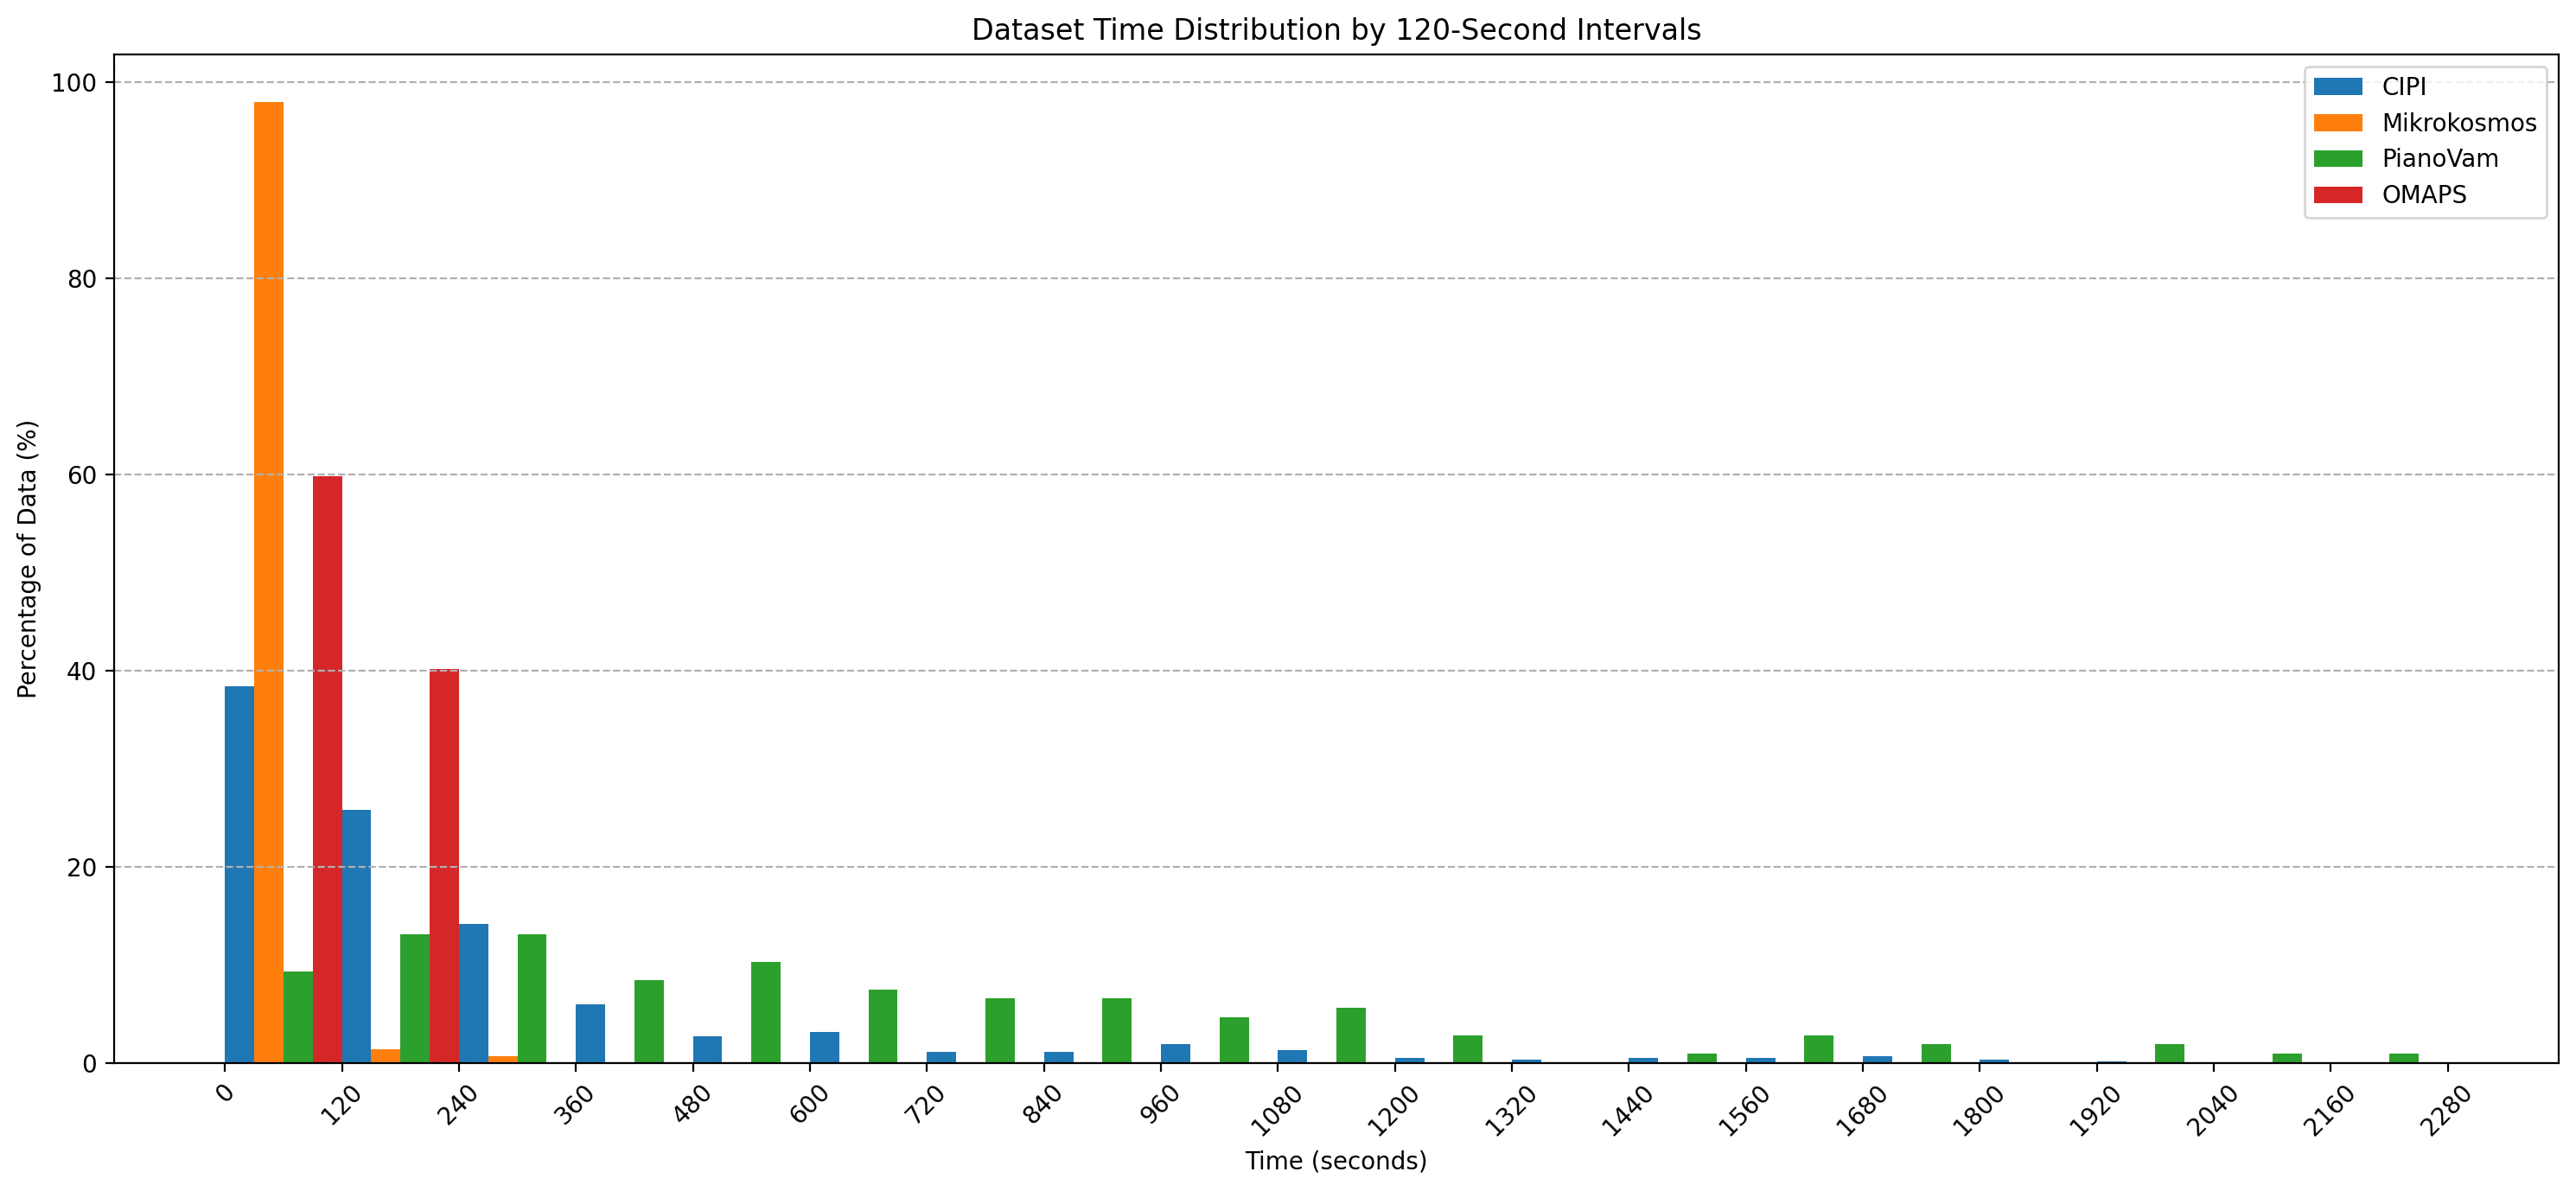

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 모든 데이터를 하나의 리스트로 결합하여 전체 시간 범위를 결정합니다.
all_data = np.concatenate([cipi_midi_len_list, mikrokosmos_midi_len_list, pianovam_midi_len_list, omaps_midi_len_list])
min_time = (int(np.floor(all_data.min())) // 60) * 60
max_time = int(np.ceil(all_data.max()))

# 120초 간격으로 시간 구간을 설정합니다.
bins = np.arange(min_time, min_time + 120 * 20, 120)

# 각 리스트에 대해 히스토그램을 계산하여 각 시간 구간에 속하는 데이터의 비율을 구합니다.
hist1, _ = np.histogram(cipi_midi_len_list, bins=bins)
hist2, _ = np.histogram(mikrokosmos_midi_len_list, bins=bins)
hist3, _ = np.histogram(pianovam_midi_len_list, bins=bins)
hist4, _ = np.histogram(omaps_midi_len_list, bins=bins)

# 각 리스트의 전체 데이터 수로 나누어 백분율로 변환합니다.
hist1_percent = hist1 / len(cipi_midi_len_list) * 100
hist2_percent = hist2 / len(mikrokosmos_midi_len_list) * 100
hist3_percent = hist3 / len(pianovam_midi_len_list) * 100
hist4_percent = hist4 / len(omaps_midi_len_list) * 100

# 막대 그래프를 그립니다.
plt.figure(figsize=(15, 7))
bar_width = 30  # 각 막대의 너비 (초 단위)

plt.bar(bins[:-1], hist1_percent, width=bar_width, align='edge', label='CIPI')
plt.bar(bins[:-1] + bar_width, hist2_percent, width=bar_width, align='edge', label='Mikrokosmos')
plt.bar(bins[:-1] + bar_width*2, hist3_percent, width=bar_width, align='edge', label='PianoVam')
plt.bar(bins[:-1] + bar_width*3, hist4_percent, width=bar_width, align='edge', label='OMAPS')

# 그래프의 제목과 축 레이블을 설정합니다.
plt.title('Dataset Time Distribution by 120-Second Intervals')
plt.xlabel('Time (seconds)')
plt.ylabel('Percentage of Data (%)')
plt.xticks(bins)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--')

# 그래프를 이미지 파일로 저장합니다.
plt.savefig('time_distribution_120s.png')

plt.tight_layout()

print(max_time)